In [1]:
### Imports ###
from collections import defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
from matplotlib import (
    pyplot as plt,
    rcParams,
    ticker,
    style,
    gridspec,
)
import numpy as np
import pandas as pd
from pandas.core.arrays.categorical import is_dict_like
import scipy
import seaborn as sns

In [2]:
N_COLORS = 10
COLORMAP = sns.color_palette("colorblind", N_COLORS)

# Common configurations for plottings
rcParams["figure.figsize"] = (3.2, 3.2)
rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "Times New Roman"
rcParams["text.usetex"] = True
rcParams["axes.spines.right"] = False   # Delete the right spine
rcParams["axes.spines.top"] = False     # Delete the top spine
rcParams["axes.grid"] = True            # Show grids in the plot
rcParams["grid.alpha"] = 0.2            # Adjust opacity of the grid
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.labelsize"] = 15
rcParams["ytick.labelsize"] = 15
rcParams["axes.labelsize"] = 17
rcParams["axes.titlesize"] = 17

MIN_MAX_RETURNS = {
    "acrobot-swingup": (0, 1000),
    "acrobot-swingup_sparse": (0, 1000),
    "ball_in_cup-catch": (0, 1000),
    "cartpole-balance": (0, 1000),
    "cartpole-balance_sparse": (0, 1000),
    "cartpole-swingup": (0, 1000),
    "cartpole-swingup_sparse": (0, 1000),
    "cartpole-two_poles": (0, 1000),
    "cartpole-three_poles": (0, 1000),
    "cheetah-run": (0, 1000),
    "finger-spin": (0, 1000),
    "finger-turn_easy": (0, 1000),
    "finger-turn_hard": (0, 1000),
    "fish-upright": (0, 1000),
    "fish-swim": (0, 1000),
    "hopper-stand": (0, 1000),
    "hopper-hop": (0, 1000),
    "lqr-lqr_2_1": (0, 1000),
    "lqr-lqr_6_2": (0, 1000),
    "manipulator-bring_ball": (0, 1000),
    "manipulator-bring_peg": (0, 1000),
    "manipulator-insert_ball": (0, 1000),
    "manipulator-insert_peg": (0, 1000),
    "pendulum-swingup": (0, 1000),
    "point_mass-easy": (0, 1000),
    "point_mass-hard": (0, 1000),
    "reacher-easy": (0, 1000),
    "reacher-hard": (0, 1000),
    "stacker-stack_2": (0, 1000),
    "stacker-stack_4": (0, 1000),
    "swimmer-swimmer6": (0, 1000),
    "swimmer-swimmer15": (0, 1000),
    "walker-stand": (0, 1000),
    "walker-walk": (0, 1000),
    "walker-run": (0, 1000),
    "dog-stand": (0, 1000),
    "dog-walk": (0, 1000),
    "dog-trot": (0, 1000),
    "dog-run": (0, 1000),
    "dog-fetch": (0, 1000),
    "humanoid-walk": (0, 1000),
    "humanoid-run": (0, 1000),
    "humanoid-run_pure_state": (0, 1000),
    "humanoid_CMU-stand": (0, 1000),
    "humanoid_CMU-walk": (0, 1000),
    "humanoid_CMU-run": (0, 1000),
    "humanoid-stand": (0, 1000),
    "quadruped-walk": (0, 1000),
    "quadruped-run": (0, 1000),
    "quadruped-escape": (0, 1000),
    "quadruped-fetch": (0, 1000),
    "Ant-v4": (-1235.0, 5557.0),
    "HalfCheetah-v4": (-652.0, 8718.0),
    "Hopper-v4": (0.0, 3632.0),
    "Humanoid-v4": (64.0, 8220.0),
    "HumanoidStandup-v4": (26654.0, 262063.0),
    "InvertedDoublePendulum-v4": (31.0, 9355.0),
    "InvertedPendulum-v4": (3.0, 1000.0),
    "Pusher-v4": (-313.0, -23.0),
    "Reacher-v4": (-99.0, -4.0),
    "Swimmer-v4": (-37.0, 352.0),
    "Walker2d-v4": (-14.0, 6192.0),
    "BattleZone": [-0.01, 1.47],
    "DoubleDunk": [-2.53, 9.68],
    "NameThisGame": [-0.29, 2.26],
    "Phoenix": [-0.11, 4.41],
    "Qbert": [-0.01, 1.37],
}

CONTINUOUS_CONTROL_ALGO = (
    "ppo",
    "sac",
    "tdmpc",
    "tdmpc2",
)

GYM_TASKS = (
    "Ant-v4",
    "HalfCheetah-v4",
    "Hopper-v4",
    "Humanoid-v4",
    "HumanoidStandup-v4",
    "InvertedDoublePendulum-v4",
    "InvertedPendulum-v4",
    "Pusher-v4",
    "Reacher-v4",
    "Swimmer-v4",
    "Walker2d-v4",
)

### Helper functions

In [3]:
def color_idx(x, margin):
    for i, m in enumerate(margin):
        if x < m:
            return i-1
    return len(margin)

### Min-max IPR function

In [4]:
def min_max_ipr(data: np.ndarray, task_name: str, percent: float=90) -> float:
    """
    Compute min max IPR.

    Args:
        data (np.ndarray): Performance of each run.
        task_name (str): Name of task to compute min-max IPR.
        percent (float): Percentage of IPR.

    Returns:
        float: Min-max IPR.
    """
    percent = max(percent, 100 - percent)
    bottom_percentile, top_percentile = np.percentile(data, [(100 - percent) / 2, 100 - ((100 - percent) / 2)], method="nearest")
    return (top_percentile - bottom_percentile) / (MIN_MAX_RETURNS[task_name][1] - MIN_MAX_RETURNS[task_name][0]) * 100

### Table of min-max IPR-90 for all the algorithm-task pairs

In [5]:
# Load all the data
DATA_DIR = Path("../data")

continuous_pd_data = defaultdict(list)
discrete_pd_data = defaultdict(list)
continuous_algo_names = []
discrete_algo_names = []
for data_file in sorted(list(DATA_DIR.glob("*.npz"))):
    data_dict = np.load(data_file)    # {task_name: 100 x 100 np.ndarray, where each row corresponds to the performance of a single run}
    algo_name = data_file.stem
    is_continuous = any(algo_name[:len(s)] == s for s in CONTINUOUS_CONTROL_ALGO)
    algo_names = continuous_algo_names if is_continuous else discrete_algo_names
    algo_names.append(algo_name)
    pd_data = continuous_pd_data if is_continuous else discrete_pd_data
    for task_name, task_perf in data_dict.items():
        perf_auc = task_perf.mean(axis=1)
        ipr = min_max_ipr(perf_auc, task_name)
        pd_data[task_name].append(ipr)

for k, v in continuous_pd_data.items():
    if k in GYM_TASKS:
        continuous_pd_data[k] = continuous_pd_data[k] + ([np.nan] * 2)

In [6]:
continuous_df = pd.DataFrame.from_dict(continuous_pd_data, orient='index', columns=continuous_algo_names)
continuous_df.head()

,ppo_default,ppo_layernorm,ppo_long_bigbatch,ppo_long_layernorm,ppo_long_lpnorm,ppo_long_pnorm,ppo_lpnorm,ppo_pnorm,sac_basic,sac_basic_layernorm,sac_default,sac_layernorm,sac_lpnorm,sac_pnorm,tdmpc,tdmpc2
Hopper-v4,23.580018,23.516222,23.580018,23.516222,19.650955,26.948148,19.650955,26.948148,29.646328,27.982691,29.646328,27.982691,37.744554,34.552268,NaN,NaN
cartpole-three_poles,1.915317,3.280649,1.915317,3.280649,1.340947,1.689836,1.340947,1.689836,4.822997,7.015577,4.822997,7.015577,6.161891,6.240874,5.716279,7.429348
pendulum-swingup,74.073250,74.656320,74.073250,74.656320,72.221410,70.509880,72.221410,70.509880,51.810000,53.658900,51.810000,53.658900,54.249900,49.151600,67.650600,16.016010
hopper-hop,10.576334,12.805898,10.576334,12.805898,0.655620,4.926315,0.655620,4.926315,3.903780,8.409802,3.903780,8.409802,5.804241,4.852783,31.995633,23.068823
point_mass-hard,8.639419,17.215456,8.639419,17.215456,9.670053,9.848869,9.670053,9.848869,2.248508,2.131903,2.248508,2.131903,1.655763,2.017021,2.528092,3.012120


In [7]:
discrete_df = pd.DataFrame.from_dict(discrete_pd_data, orient="index", columns=discrete_algo_names)
discrete_df.head()

,dqn,rainbow
BattleZone,31.061430,28.086385
DoubleDunk,32.641753,3.059034
NameThisGame,7.935720,6.421171
Phoenix,7.297996,23.309441
Qbert,8.470113,11.236858


### Min-max IPR-90 bar plots

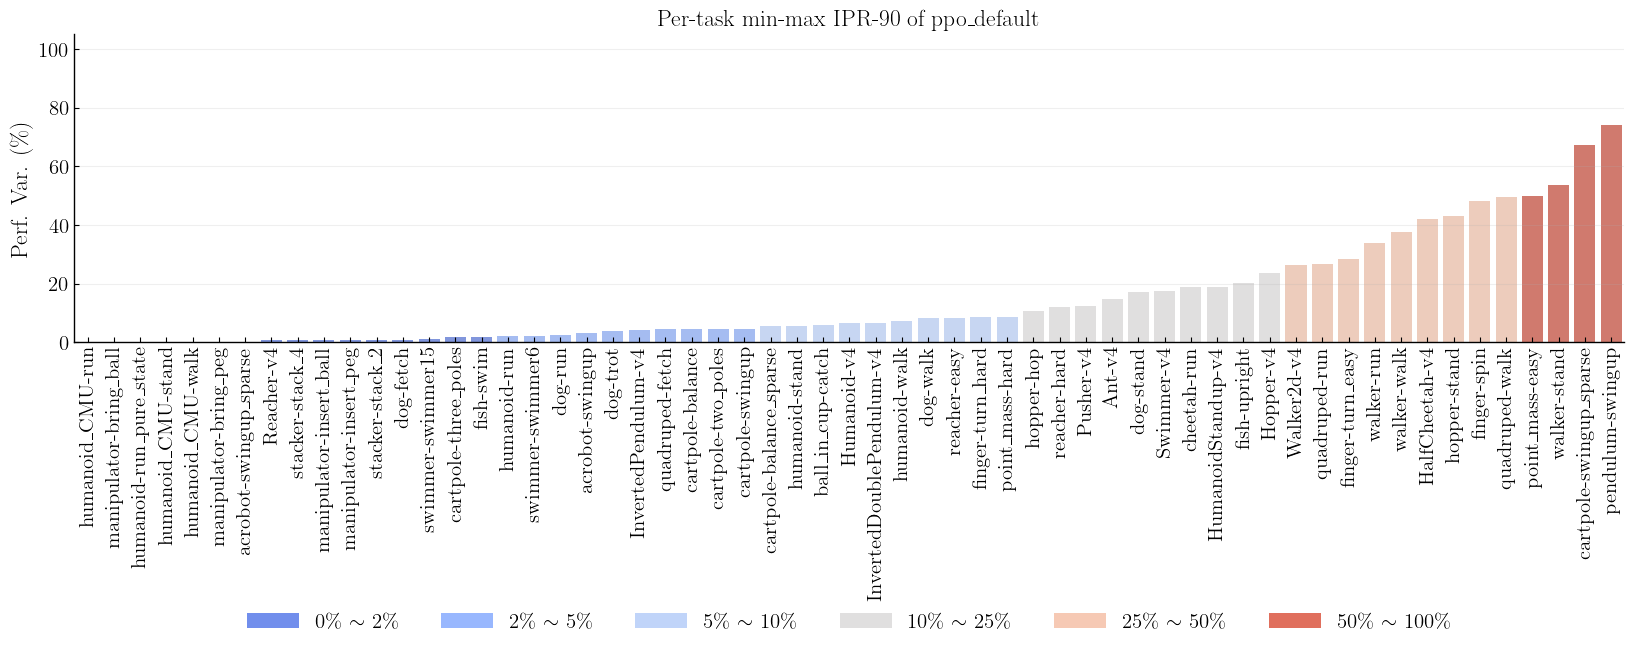

In [8]:
margin = [0, 2, 5, 10, 25, 50]
palette = sns.color_palette("coolwarm", len(margin) + 1)
df = continuous_df           # Change to desired dataframe
algorithm = "ppo_default"    # Change to desired algorithm name

fig, ax = plt.subplots(1, 1, figsize=(20, 4))
algo_ipr = df[algorithm].dropna().sort_values()
color_indices = [color_idx(algo_ipr[j], margin) for j in range(len(algo_ipr))]
colors = [palette[i] for i in color_indices]
sns.barplot(
    data=pd.DataFrame(algo_ipr),
    x=algo_ipr.index,
    y=algorithm,
    palette=colors,
    alpha=0.9,
    ax=ax,
)

ax.set_ylim(0.0, 105.0)
ax.set_ylabel("Perf. Var. (\%)")
ax.set_xlabel(None)
for label in ax.get_xticklabels():
    label.set_rotation(90)
    label.set_ha("center")

color_indices = sorted(list(set(color_indices)))
legends, labels = [], []
for cidx in color_indices:
    legends.append(plt.Rectangle((0, 0), 2, 1, facecolor=palette[cidx], alpha=0.9))
    labels.append(fr"{margin[cidx]}\% $\sim$ {margin[cidx+1]}\%" if cidx != len(margin) else r"50\% $\sim$ 100\%")

ax.legend(
    legends,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -1.0),
    ncol=len(legends),
    frameon=False,
    handlelength=2.5,
    fontsize=15,
)

ax.set_title(f"Per-task min-max IPR-90 of {algorithm}")
plt.show()